In [1]:
import sys

import numpy as np
from pathlib import Path

# 'services', 'model_functions' e 'iSpec_functions' están en 'models', así que
# hay que poner esa carpeta en 'sys.path' antes de importarlos. Para eso
# localizamos 'solution' subiendo desde el directorio de trabajo, sin suponer
# dónde arranca el kernel: sirve tanto la carpeta de este cuaderno como 'models'
# o la raíz del repositorio. Su marca es el fichero 'pyproject.toml'. iSpec
# tampoco se instala como dependencia, pero de montarlo se encarga
# 'iSpec_functions', que lo añade a 'sys.path' al importarse.
SOLUTION_DIR = next(
    candidate
    for parent in (Path.cwd(), *Path.cwd().parents)
    for candidate in (parent, parent / "solution")
    if (candidate / "pyproject.toml").is_file()
)

sys.path.insert(0, str(SOLUTION_DIR / "models"))

from services.paths import DATA_DIR, model_paths, test_data_path

# Ficheros que deja el entrenamiento de cada modelo, nombrados por la convención
# que comparten todos los cuadernos y que reúne 'services/paths.py': el modelo
# en esta misma carpeta, por ser la salida del cuaderno; a su lado 'training'
# con el registro de cómo se entrenó; y fuera de ella las predicciones, en
# 'models/data/predictions', y la tabla del análisis con iSpec, en
# 'models/data/ispec_deviations': no son un checkpoint del entrenamiento sino
# el dato que consume la comparativa entre arquitecturas.
(
    GRU_MODEL_PATH,
    GRU_HISTORY_PATH,
    GRU_SUMMARY_PATH,
    GRU_PREDICTIONS_PATH,
    GRU_ISPEC_PATH,
) = model_paths("gru", "rnn")

(
    BIRNN_MODEL_PATH,
    BIRNN_HISTORY_PATH,
    BIRNN_SUMMARY_PATH,
    BIRNN_PREDICTIONS_PATH,
    BIRNN_ISPEC_PATH,
) = model_paths("birnn", "rnn")

(
    ATTENTION_MODEL_PATH,
    ATTENTION_HISTORY_PATH,
    ATTENTION_SUMMARY_PATH,
    ATTENTION_PREDICTIONS_PATH,
    ATTENTION_ISPEC_PATH,
) = model_paths("birnn-attention", "rnn")

# El conjunto de test que comparten los tres va en 'models/data/test', carpeta
# común a todos los cuadernos porque todos parten del mismo conjunto de test.
# Esta celda no carga datos, de modo que la recarga de una sesión anterior solo
# necesita ejecutar esta celda y las de recarga.
TEST_DATA_PATH = test_data_path("rnn")

# Tamaño de lote del entrenamiento, guardado también en cada resumen
batch_size = 64

print("Carpeta de trabajo:", SOLUTION_DIR)

Carpeta de trabajo: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution


In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
import matplotlib.pyplot as plt

import os

os.environ["NUMEXPR_MAX_THREADS"] = "8"
os.environ["NUMEXPR_NUM_THREADS"] = "8"

# El nombre del fichero puede llevar la fecha de generación como prefijo
candidates = (
    sorted(DATA_DIR.glob("*processed_data_no_duplicates.npz"))
    + sorted(DATA_DIR.glob("*processed_data.npz"))
)
processed_path = candidates[0]
print("Usando:", processed_path)

data = np.load(processed_path)

print(data.files)

2026-09-06 12:21:59.949854: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-06 12:22:00.059159: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-06 12:22:02.534975: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Usando: /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/data/2026-08-16_processed_data_no_duplicates.npz
['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [3]:
# Datos de Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos de SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

Aplicamos la normalización que mejores resultados dio en la red neuronal densa.

In [77]:
from services.normalization import normalize_splits

# Cada espectro se normaliza con la mediana de su propio flujo absoluto, tanto
# la entrada de Gaia como el objetivo de SDSS
(X_train_norm_median_spec, X_val_norm_median_spec,
 X_test_norm_median_spec, X_scale_test) = normalize_splits(X_train, X_val, X_test)

(y_train_norm_median_spec, y_val_norm_median_spec,
 y_test_norm_median_spec, y_scale_test) = normalize_splits(y_train, y_val, y_test)

Preparamos los datos para la RNN añadiendo una tercera dimensión para las variables por cada paso (punto de la longitud de onda).

In [78]:
X_train_rnn = X_train_norm_median_spec[..., np.newaxis]
X_val_rnn = X_val_norm_median_spec[..., np.newaxis]
X_test_rnn = X_test_norm_median_spec[..., np.newaxis]

print("X_train_rnn:", X_train_rnn.shape)
print("X_val_rnn:", X_val_rnn.shape)
print("X_test_rnn:", X_test_rnn.shape)

X_train_rnn: (32656, 201, 1)
X_val_rnn: (4082, 201, 1)
X_test_rnn: (4082, 201, 1)


In [79]:
from services.checkpoints import save_test_data

# Guardamos las variables del conjunto de test que consumen las celdas
# posteriores al entrenamiento, para poder ejecutarlas sin repetir estas celdas.
# Las versiones normalizadas no se guardan: se rehacen en la recarga a partir de
# las escalas, en un solo paso.
save_test_data(
    TEST_DATA_PATH,
    X_test=X_test,
    y_test=y_test,
    X_id_test=X_id_test,
    y_id_test=y_id_test,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    X_scale_test=X_scale_test,
    y_scale_test=y_scale_test
)

PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/data/test/rnn_test_data.npz')

Definimos un primer modelo base para hacer pruebas.

In [80]:
n_gaia = X_train_rnn.shape[1]
n_features = X_train_rnn.shape[2]
n_sdss = y_train_norm_median_spec.shape[1]

Definimos las mismas funciones que en el caso denso. 

In [81]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

In [82]:
model_GRU = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    layers.GRU(128, return_sequences=False),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(n_sdss)
])

model_GRU.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_GRU.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_13 (GRU)                    │ (None, 128)            │        50,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_20 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_21 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,374,314 (12.87 MB)

 Trainable params: 3,374,314 (12.87 MB)

 Non-trainable params: 0 (0.00 B)

El entrenamiento deja en `models/rnn` tres ficheros por cada uno de los tres modelos del cuaderno, más un único `rnn_test_data.npz` con el conjunto de test que comparten. Los modelos, que son la salida del cuaderno, quedan en la propia carpeta; el registro de cada entrenamiento, en `training`, y el conjunto de test, en `models/data/test`, común a todos los cuadernos. Con ellos, las celdas de evaluación y análisis pueden ejecutarse en una sesión nueva sin repetir el entrenamiento ni volver a cargar el `.npz` de datos completo:

- `<modelo>.keras`: el modelo con la mejor pérdida de validación, guardado cada vez que mejora.
- `training/<modelo>_training_history.csv`: una fila por época con todas las métricas, escrita al final de cada época. Es una **tabla**, así que la escribe directamente el callback `CSVLogger` de Keras, sin código propio, y queda legible y comparable entre modelos. Un CSV además admite los `NaN` de una época divergente, que en JSON no serían válidos.
- `training/<modelo>_training_summary.json`: el resumen del entrenamiento (mejor época, tamaño de lote y métricas de test). Son **datos sueltos y heterogéneos** que no caben en una tabla ni en un contenedor de arrays, y en JSON siguen siendo legibles y versionables en Git.
- `models/data/test/rnn_test_data.npz`: las variables del conjunto de test que consumen las celdas posteriores (`X_test`, `y_test`, los identificadores, las longitudes de onda y las escalas de normalización). Son **arrays** de cientos de megabytes, para los que `.npz` es el único formato razonable de los tres: conserva forma y `dtype` sin código de conversión y se escribe y lee en menos de un segundo, mientras que en JSON o CSV los mismos datos ocuparían varias veces más en texto. Sobre todo, conserva los identificadores de Gaia como `int64`: son de hasta 19 dígitos y más de la mitad no se representan de forma exacta en el `float64` al que los llevaría un CSV o un JSON leído como decimal.

La lógica de guardado y recarga vive en `models/services/checkpoints.py`, compartida por todos los cuadernos de entrenamiento. De la normalización se ocupa `models/services/normalization.py`, que reúne los esquemas de todos los cuadernos. La normalización del conjunto de test no se guarda: se rehace a partir de sus escalas. De las predicciones se ocupa `models/services/predictions.py`, que las guarda aparte, en `models/data/predictions/<modelo>_predictions.npz`: no son un checkpoint del entrenamiento sino el dato que consume la comparativa entre arquitecturas.

In [83]:
from tensorflow.keras.callbacks import CSVLogger, ModelCheckpoint

from services.checkpoints import save_training_summary

# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model_GRU = ModelCheckpoint(
    GRU_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history_GRU = CSVLogger(GRU_HISTORY_PATH)

history_GRU = model_GRU.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=25,
    batch_size=batch_size,
    callbacks=[
        save_best_epoch_model_GRU,
        early_stop,
        reduce_lr,
        save_training_history_GRU
    ],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model_GRU.save(GRU_MODEL_PATH)

model_data_GRU = history_GRU.history
save_training_summary(
    GRU_SUMMARY_PATH,
    model_data_GRU,
    model_path=GRU_MODEL_PATH,
    history_path=GRU_HISTORY_PATH,
    batch_size=batch_size
)

Epoch 1/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 425ms/step - loss: 0.0917 - mae: 0.2645 - mse: 0.2061
Epoch 1: val_loss improved from None to 0.01182, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/rnn/gru.keras

Epoch 1: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/rnn/gru.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 238s 451ms/step - loss: 0.0917 - mae: 0.2645 - mse: 0.2061 - val_loss: 0.0118 - val_mae: 0.0877 - val_mse: 0.0311 - learning_rate: 1.0000e-04
Epoch 2/25
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - loss: 0.0096 - mae: 0.0752 - mse: 0.0236
Epoch 2: val_loss improved from 0.01182 to 0.00846, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/rnn/gru.keras

Epoch 2: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/rnn/gru.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 260s 448ms/step - loss: 0.0096 - mae: 0.0752 - mse: 0.0236 - val_lo

{'model': 'gru.keras',
 'history': 'gru_training_history.csv',
 'updated': '2026-09-01T23:04:06',
 'batch_size': 64,
 'epochs_completed': 19,
 'best_epoch': 19,
 'test_metrics': None}

Recarga desde el checkpoint. Estas dos celdas recuperan todas las variables que necesitan las celdas siguientes: el conjunto de test —común a los tres modelos— y, del trío de ficheros del modelo, sus pesos, su historial y su resumen. Ejecutando la primera celda del cuaderno —la de rutas, que no carga datos— y después estas, el análisis funciona sin reentrenar y sin volver a cargar el `.npz` de datos completo.

In [84]:
from services.checkpoints import load_test_data
from services.normalization import normalize

# Variables del conjunto de test que consumen las celdas de análisis de los tres
# modelos, así que basta con ejecutar esta celda una vez por sesión
test_data = load_test_data(TEST_DATA_PATH)

X_test = test_data["X_test"]
y_test = test_data["y_test"]
X_id_test = test_data["X_id_test"]
y_id_test = test_data["y_id_test"]
gaia_wavelength = test_data["gaia_wavelength"]
sdss_wavelength = test_data["sdss_wavelength"]
X_scale_test = test_data["X_scale_test"]
y_scale_test = test_data["y_scale_test"]

# La normalización se rehace a partir de las escalas guardadas, en lugar de
# ocupar sitio en el `.npz`
X_test_norm_median_spec = normalize(X_test, X_scale_test)
y_test_norm_median_spec = normalize(y_test, y_scale_test)
X_test_rnn = X_test_norm_median_spec[..., np.newaxis]

In [5]:
from services.checkpoints import load_checkpoint

model_GRU, model_data_GRU, summary_GRU = load_checkpoint(
    GRU_MODEL_PATH, GRU_HISTORY_PATH, GRU_SUMMARY_PATH
)

print("Checkpoint de", summary_GRU["updated"])
print(
    "Épocas completadas:", summary_GRU["epochs_completed"],
    "| mejor época:", summary_GRU["best_epoch"]
)
print("Métricas de test:", summary_GRU["test_metrics"])

2026-09-06 12:23:34.384130: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Checkpoint de 2026-09-01T23:04:20
Épocas completadas: 19 | mejor época: 19
Métricas de test: {'loss': 0.004363771993666887, 'mae': 0.04799491912126541, 'mse': 0.010978998616337776}


In [86]:
from services.checkpoints import save_training_summary

test_results_GRU = model_GRU.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    GRU_SUMMARY_PATH,
    model_data_GRU,
    test_results_GRU,
    model_path=GRU_MODEL_PATH,
    history_path=GRU_HISTORY_PATH,
    batch_size=batch_size
)

print(test_results_GRU)

128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - loss: 0.0044 - mae: 0.0480 - mse: 0.0110
{'loss': 0.004363771993666887, 'mae': 0.04799491912126541, 'mse': 0.010978998616337776}


In [126]:
from services.normalization import denormalize, normalize
from services.predictions import predict_test_set, save_predictions

# Predicciones del modelo GRU. La celda parte del `.keras` del modelo y del
# `.npz` de test, así que se ejecuta suelta tras la de rutas: no reentrena, no
# vuelve a cargar el `.npz` de datos completo y no necesita las variables que
# dejen en memoria las demás celdas del cuaderno.
y_pred_spec_GRU = predict_test_set(
    GRU_MODEL_PATH,
    TEST_DATA_PATH,
    # La red recurrente espera un paso por punto del espectro y una variable
    # por paso, de ahí la tercera dimensión
    build_input=lambda test: normalize(
        test["X_test"], test["X_scale_test"]
    )[..., None],
    denormalize=lambda y_norm, test: denormalize(y_norm, test["y_scale_test"])
)

# Las guardamos para la comparativa entre arquitecturas, en su propio cuaderno
save_predictions(GRU_PREDICTIONS_PATH, y_pred=y_pred_spec_GRU)

2026-09-03 16:49:49.460622: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-03 16:49:49.582586: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-03 16:49:52.029563: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-03 16:49:53.457404: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


128/128 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step


PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/data/predictions/gru_predictions.npz')

In [89]:
# Importamos Funciones iSpec
from iSpec_functions import (
    load_ispec_resources,
    load_gaia_table,
    analyze_sample_real_vs_pred,
    analyze_ispec_errors
)
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

# Cargamos Resources
resources = load_ispec_resources()

# Cargamos la tabla de Gaia guardada en local
gaia_data_df = load_gaia_table()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/lib/iSpec/ispec/atmospheres.py:349: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  delaunay_triangulations, kdtree = pickle.load(open(cache_filename, 'rb'))



Recursos de iSpec cargados correctamente.
Tabla de Gaia cargada: 121890 objetos.


In [90]:
# Recargamos si ha habido modificaciones
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [91]:
results_df_GRU = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_spec_GRU,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Error analizando espectro real
Error analizando espectro real



Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real


[2026-09-02 01:16:24,387] [WARNING] [atmospheres:_interpolate:110]: Target point '6891.025812708268 4.400750870107666 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-02 01:16:25,564] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Error analizando espectro real
Espectros analizados: 250 | ajustes del espectro real reutilizados: 250


In [92]:
GRU_ISPEC_PATH.parent.mkdir(parents=True, exist_ok=True)

results_df_GRU.to_csv(
    GRU_ISPEC_PATH,
    index=False
)

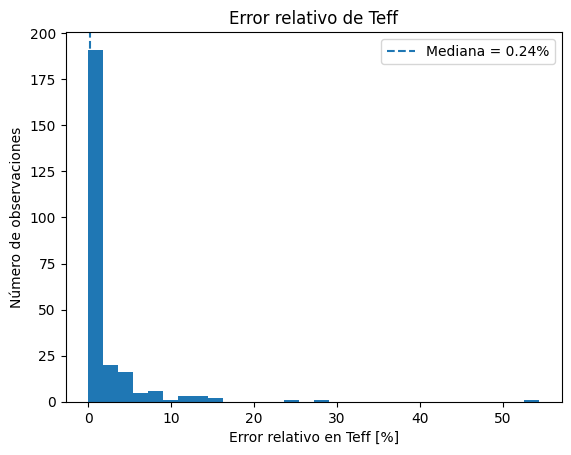

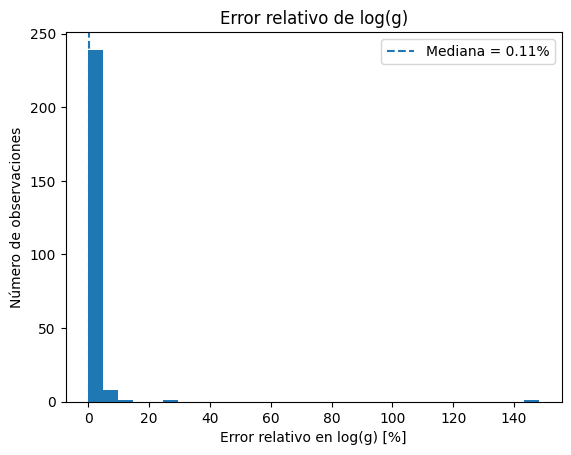

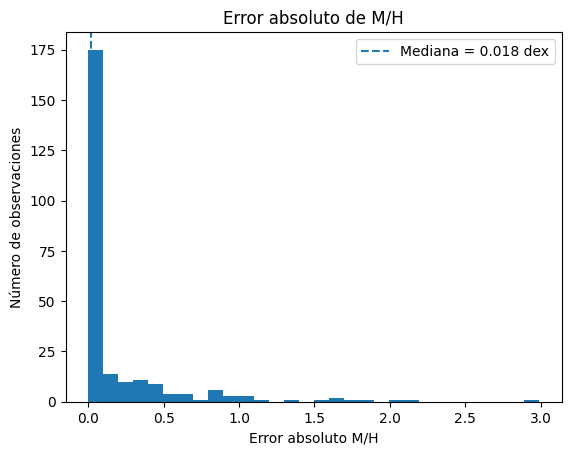

In [93]:
error_df_GRU = analyze_ispec_errors(results_df_GRU)

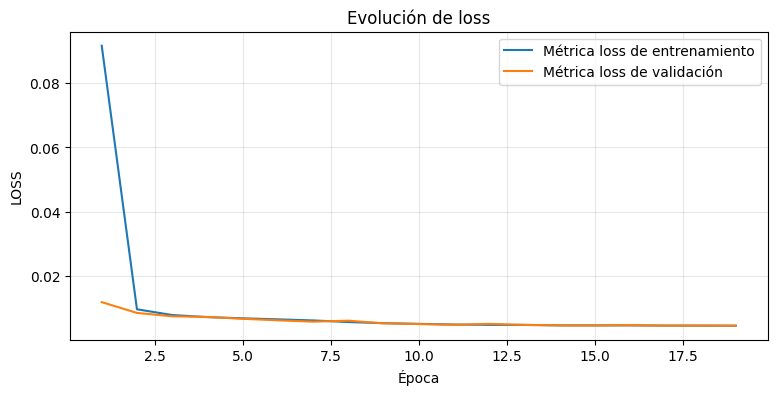

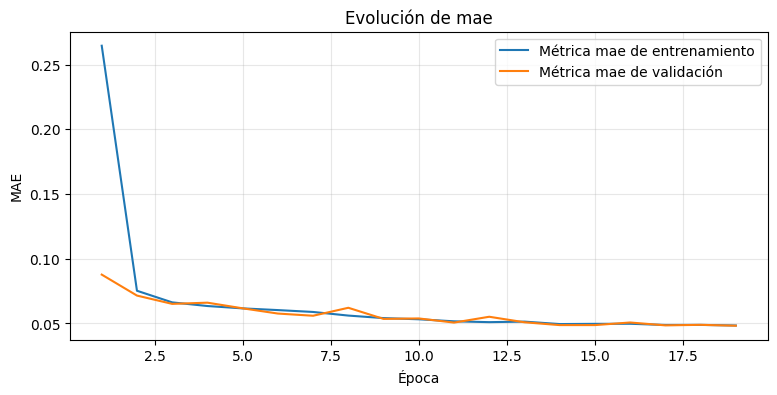

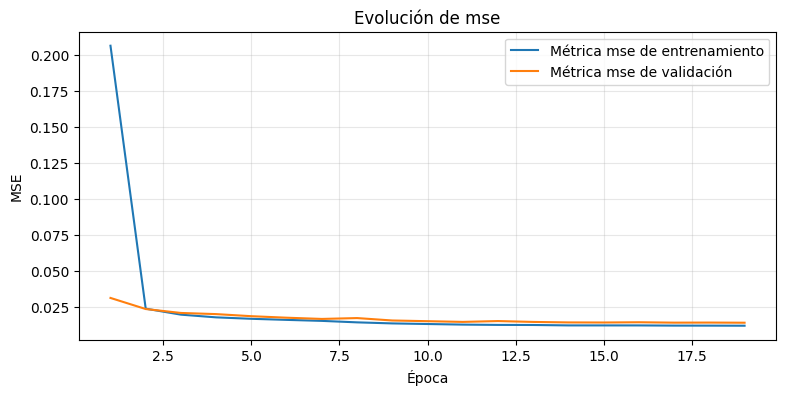

In [6]:
# Importamos funciones a usar para analizar resultados
from model_functions import plot_training_metrics

plot_training_metrics(model_data_GRU)


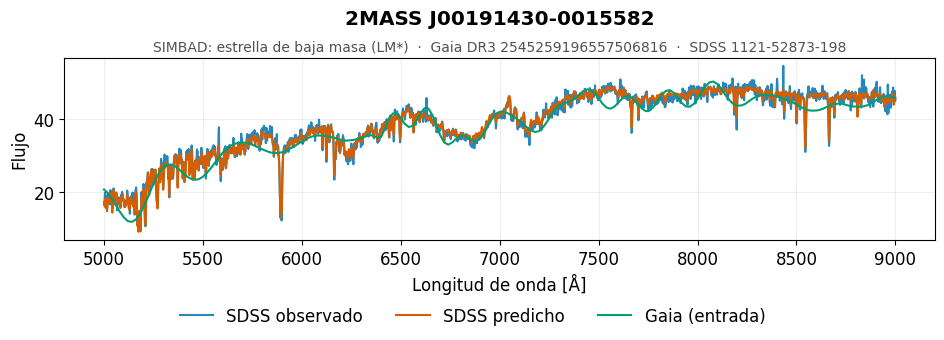

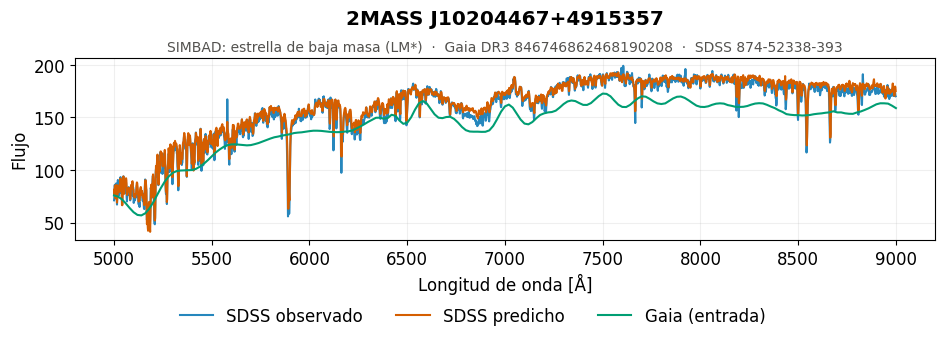

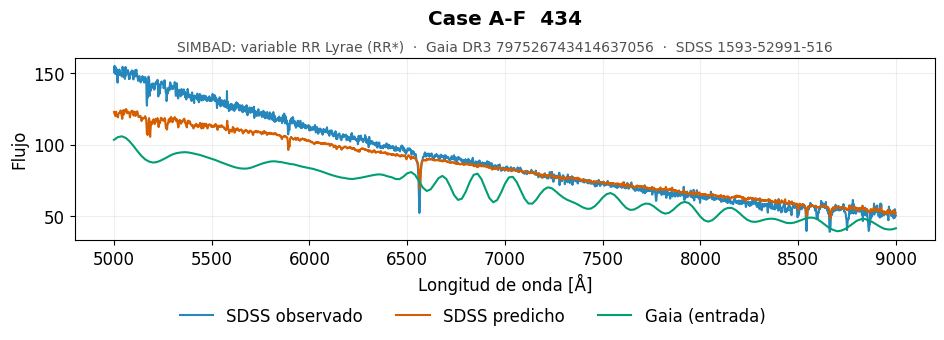

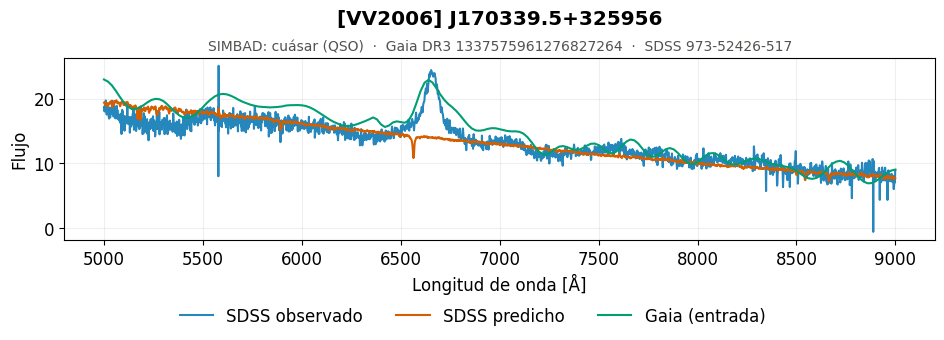

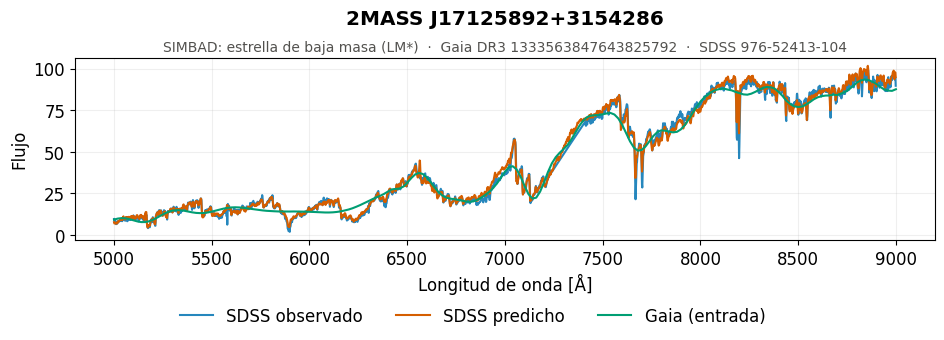

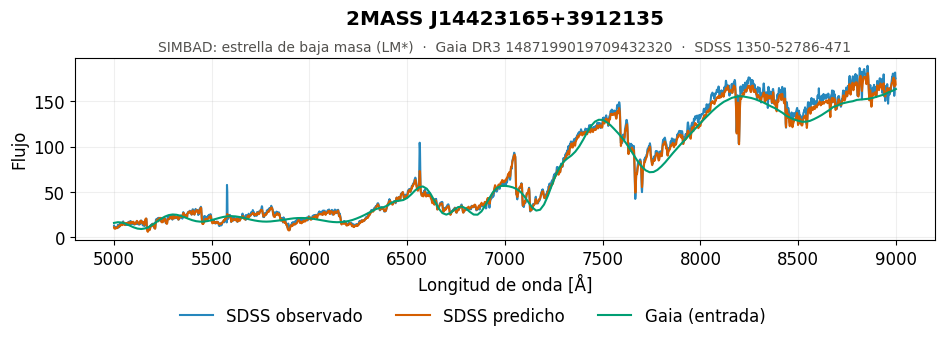

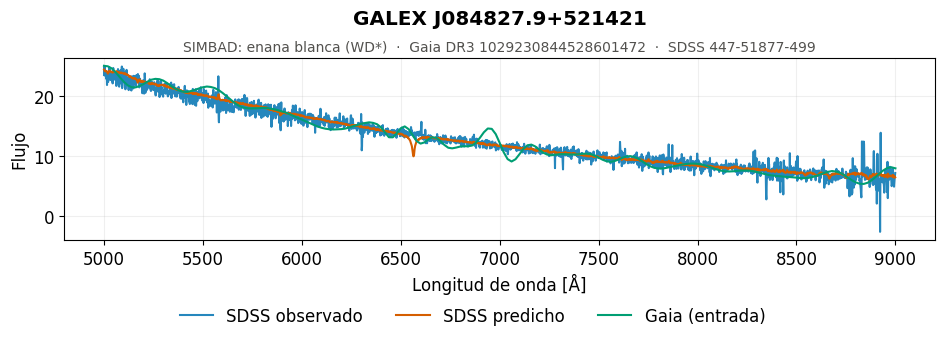

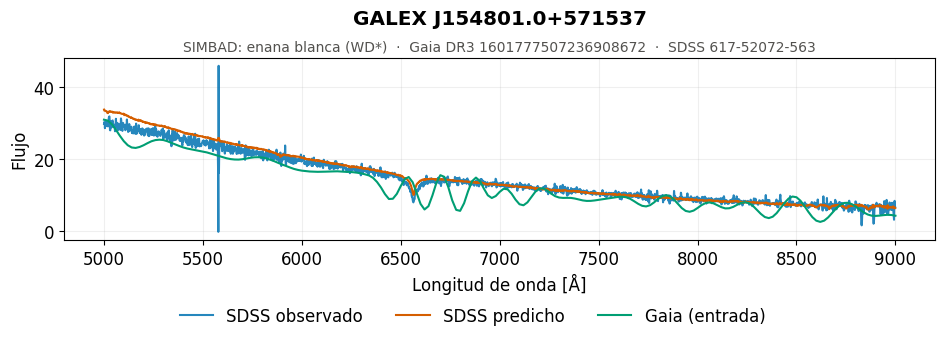

Imágenes guardadas en /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images


[PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/gru_main_sequence_central_2545259196557506816.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/gru_main_sequence_central_846746862468190208.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/gru_main_sequence_left_797526743414637056.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/gru_main_sequence_left_1337575961276827264.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/gru_main_sequence_right_1333563847643825792.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/gru_main_sequence_right_1487199019709432320.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/gru_white_dwarfs_1029230844528601472.png'),
 PosixPath('/home/javier-ca

In [2]:
import sys

# 'plotting.py' vive en 'solution/services', y la celda de rutas solo añade
# 'models' a 'sys.path'. Las dos carpetas se llaman 'services', así que Python
# las une en un único paquete del que salen tanto 'services.paths' como
# 'services.plotting'
sys.path.insert(0, str(SOLUTION_DIR))

from services.plotting import SELECTED_OBJECTS_PATH, plot_selected_objects

# Comparativa sobre los mismos objetos en todos los cuadernos: la pareja de
# cada zona del diagrama HR que eligió 'services/simbad.py', encabezada por el
# nombre celeste oficial de cada objeto. Las figuras quedan guardadas en
# 'models/images' con el nombre que cita la memoria.
#
# La celda parte del CSV de objetos y de los `.npz` de test y de predicciones,
# así que se ejecuta suelta tras la de rutas: no reentrena, no vuelve a cargar
# el `.npz` de datos completo y no necesita las variables que dejen en memoria
# las demás celdas del cuaderno.
plot_selected_objects(
    SELECTED_OBJECTS_PATH,
    TEST_DATA_PATH,
    GRU_PREDICTIONS_PATH,
    "gru"
)


In [96]:
# La capa de atención hace falta también al recargar el modelo entrenado: el
# `.keras` guarda su nombre, pero no su código. Por eso trae sus propios
# imports, de modo que la recarga pueda ejecutar esta celda suelta.
import tensorflow as tf
from tensorflow.keras import layers


class AttentionPooling(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):
        self.attention_dense = layers.Dense(1)
        super().build(input_shape)

    def call(self, inputs):
        scores = self.attention_dense(inputs)
        weights = tf.nn.softmax(scores, axis=1)
        context = tf.reduce_sum(inputs * weights, axis=1)
        return context


In [97]:
early_stop_earlier = EarlyStopping(
    monitor="val_loss",
    patience=2,
    min_delta=1e-4,
    restore_best_weights=True
)

reduce_lr_earlier = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=1,
    min_lr=1e-6,
    verbose=1
)


In [98]:
model_birnn_simple = models.Sequential([
    layers.Input(shape=(n_gaia, n_features)),

    layers.Bidirectional(layers.GRU(128, return_sequences=False)),

    layers.Dense(512),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(1024),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(1024, activation="elu"),

    layers.Dense(n_sdss)
])

model_birnn_simple.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_birnn_simple.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 256)            │       100,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_22 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_23 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,589,354 (21.32 MB)

 Trainable params: 5,589,354 (21.32 MB)

 Non-trainable params: 0 (0.00 B)

In [99]:
from services.checkpoints import save_training_summary

# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model_birnn = ModelCheckpoint(
    BIRNN_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history_birnn = CSVLogger(BIRNN_HISTORY_PATH)

history_birnn_simple = model_birnn_simple.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=20,
    batch_size=batch_size,
    callbacks=[
        save_best_epoch_model_birnn,
        early_stop_earlier,
        reduce_lr_earlier,
        save_training_history_birnn
    ],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model_birnn_simple.save(BIRNN_MODEL_PATH)

model_data_birnn = history_birnn_simple.history
save_training_summary(
    BIRNN_SUMMARY_PATH,
    model_data_birnn,
    model_path=BIRNN_MODEL_PATH,
    history_path=BIRNN_HISTORY_PATH,
    batch_size=batch_size
)

Epoch 1/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 309ms/step - loss: 0.0346 - mae: 0.1363 - mse: 0.0794
Epoch 1: val_loss improved from None to 0.00612, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/rnn/birnn.keras

Epoch 1: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/rnn/birnn.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 176s 327ms/step - loss: 0.0346 - mae: 0.1363 - mse: 0.0794 - val_loss: 0.0061 - val_mae: 0.0618 - val_mse: 0.0179 - learning_rate: 1.0000e-04
Epoch 2/20
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/step - loss: 0.0057 - mae: 0.0592 - mse: 0.0145
Epoch 2: val_loss improved from 0.00612 to 0.00528, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/rnn/birnn.keras

Epoch 2: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/rnn/birnn.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 165s 323ms/step - loss: 0.0057 - mae: 0.0592 - mse: 0.0145 

{'model': 'birnn.keras',
 'history': 'birnn_training_history.csv',
 'updated': '2026-09-02T01:43:03',
 'batch_size': 64,
 'epochs_completed': 8,
 'best_epoch': 8,
 'test_metrics': None}

Recarga desde el checkpoint del modelo bidireccional. Necesita la celda de rutas del principio del cuaderno y la de recarga del conjunto de test.

In [7]:
from services.checkpoints import load_checkpoint

model_birnn_simple, model_data_birnn, summary_birnn = load_checkpoint(
    BIRNN_MODEL_PATH, BIRNN_HISTORY_PATH, BIRNN_SUMMARY_PATH
)

print("Checkpoint de", summary_birnn["updated"])
print(
    "Épocas completadas:", summary_birnn["epochs_completed"],
    "| mejor época:", summary_birnn["best_epoch"]
)
print("Métricas de test:", summary_birnn["test_metrics"])

Checkpoint de 2026-09-02T01:43:14
Épocas completadas: 8 | mejor época: 8
Métricas de test: {'loss': 0.004389064386487007, 'mae': 0.05004473030567169, 'mse': 0.010995296761393547}


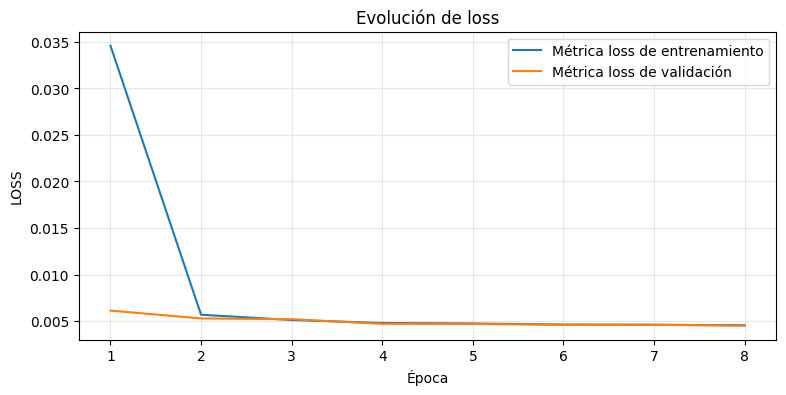

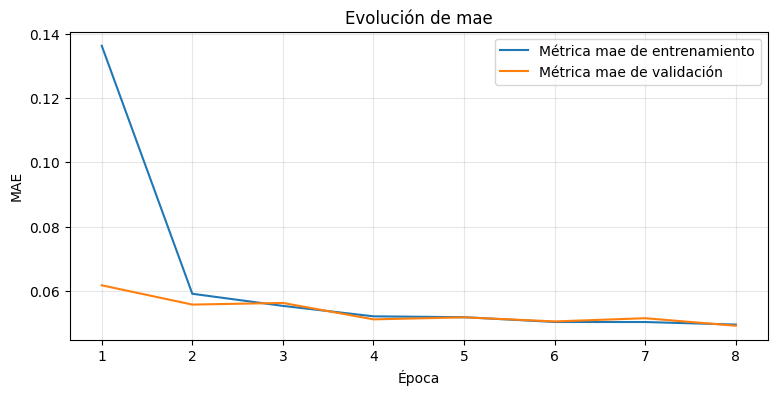

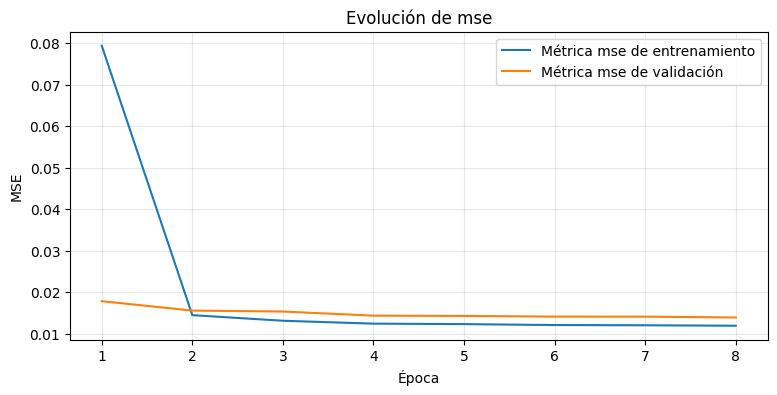

In [8]:
from model_functions import plot_training_metrics

plot_training_metrics(model_data_birnn)

In [102]:
from services.checkpoints import save_training_summary

test_results_birnn_simple = model_birnn_simple.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    BIRNN_SUMMARY_PATH,
    model_data_birnn,
    test_results_birnn_simple,
    model_path=BIRNN_MODEL_PATH,
    history_path=BIRNN_HISTORY_PATH,
    batch_size=batch_size
)

print(test_results_birnn_simple)

128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 0.0044 - mae: 0.0500 - mse: 0.0110
{'loss': 0.004389064386487007, 'mae': 0.05004473030567169, 'mse': 0.010995296761393547}


In [127]:
from services.normalization import denormalize, normalize
from services.predictions import predict_test_set, save_predictions

# Predicciones del modelo bidireccional
y_pred_spec_birnn_simple = predict_test_set(
    BIRNN_MODEL_PATH,
    TEST_DATA_PATH,
    build_input=lambda test: normalize(
        test["X_test"], test["X_scale_test"]
    )[..., None],
    denormalize=lambda y_norm, test: denormalize(y_norm, test["y_scale_test"])
)

save_predictions(BIRNN_PREDICTIONS_PATH, y_pred=y_pred_spec_birnn_simple)

128/128 ━━━━━━━━━━━━━━━━━━━━ 9s 63ms/step


PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/data/predictions/birnn_predictions.npz')

In [105]:
from iSpec_functions import (
    analyze_sample_real_vs_pred,
    load_ispec_resources,
    load_gaia_table
)

# Los dos cargadores guardan en caché de módulo lo que leen, así que repetir
# aquí la llamada no vuelve a leer del disco los recursos de iSpec ni la tabla
# de Gaia: solo recupera lo que ya cargó la primera sección que los pidiera
resources = load_ispec_resources()
gaia_data_df = load_gaia_table()

results_df_birnn_simple = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_spec_birnn_simple,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Error analizando espectro real
Error analizando espectro real



Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Espectros analizados: 250 | ajustes del espectro real reutilizados: 250


In [106]:
BIRNN_ISPEC_PATH.parent.mkdir(parents=True, exist_ok=True)

results_df_birnn_simple.to_csv(
    BIRNN_ISPEC_PATH,
    index=False
)

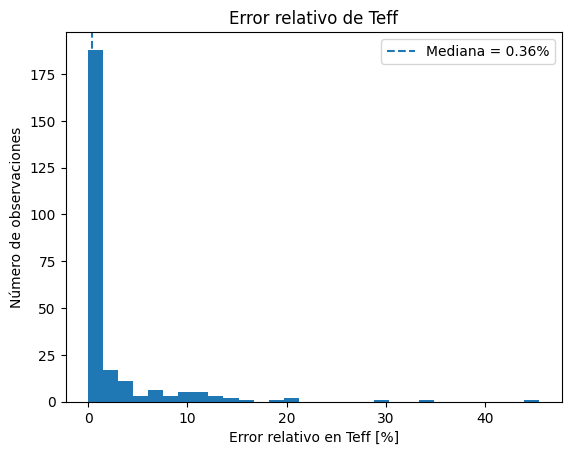

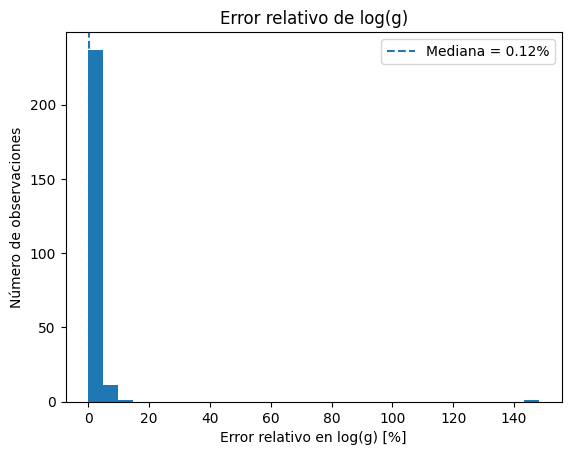

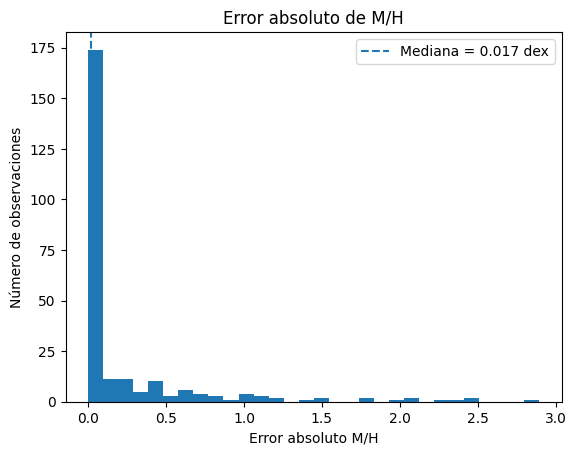

In [107]:
from iSpec_functions import analyze_ispec_errors

error_birnn_simple = analyze_ispec_errors(results_df_birnn_simple)

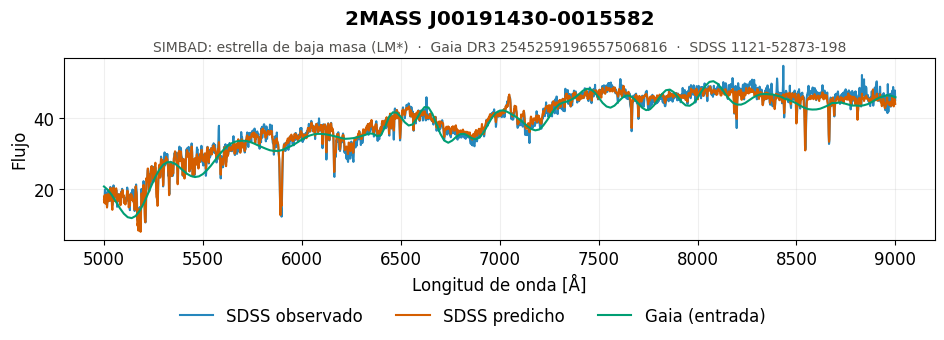

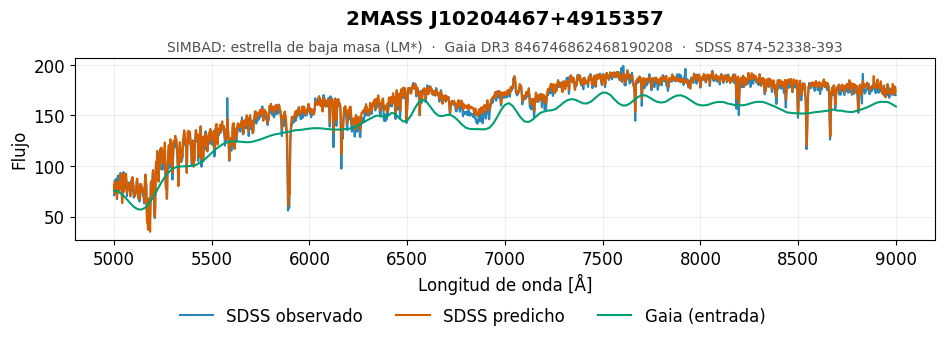

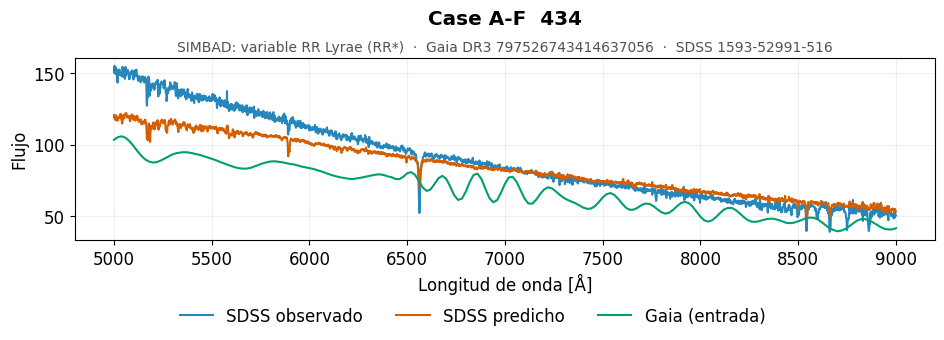

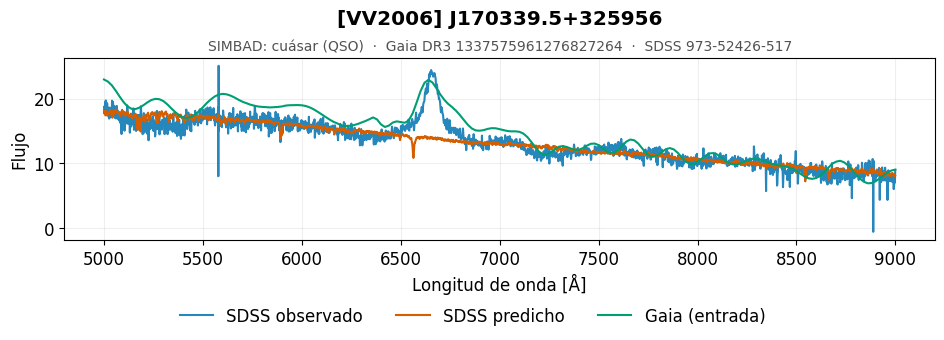

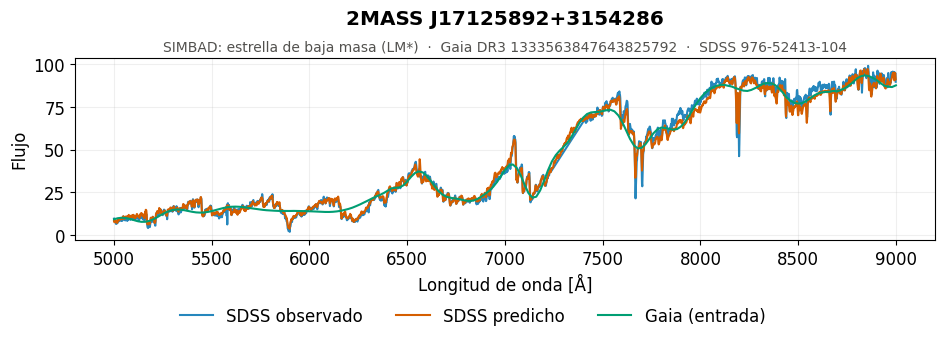

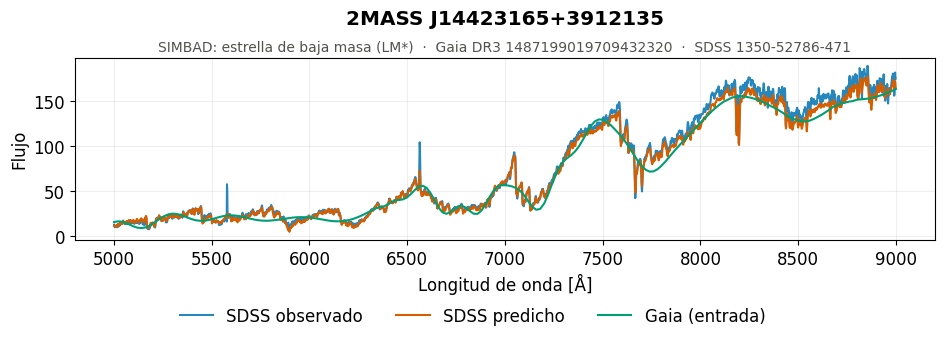

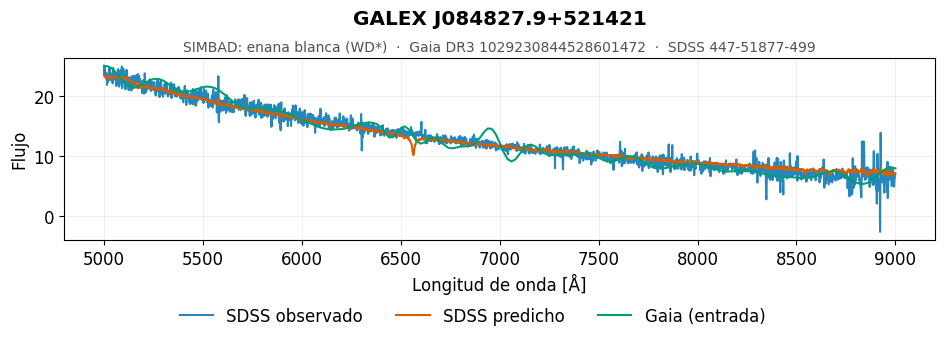

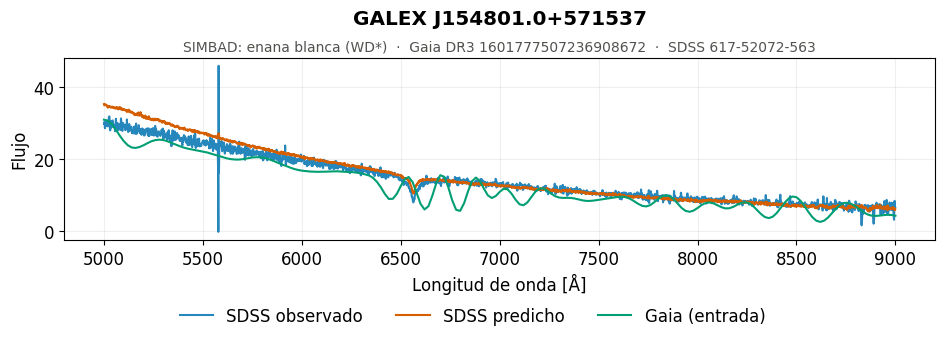

Imágenes guardadas en /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images


[PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn_main_sequence_central_2545259196557506816.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn_main_sequence_central_846746862468190208.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn_main_sequence_left_797526743414637056.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn_main_sequence_left_1337575961276827264.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn_main_sequence_right_1333563847643825792.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn_main_sequence_right_1487199019709432320.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn_white_dwarfs_1029230844528601472.png'),
 PosixPath('/

In [3]:
import sys

# 'plotting.py' vive en 'solution/services', y la celda de rutas solo añade
# 'models' a 'sys.path'. Las dos carpetas se llaman 'services', así que Python
# las une en un único paquete del que salen tanto 'services.paths' como
# 'services.plotting'
sys.path.insert(0, str(SOLUTION_DIR))

from services.plotting import SELECTED_OBJECTS_PATH, plot_selected_objects

# Comparativa sobre los mismos objetos en todos los cuadernos: la pareja de
# cada zona del diagrama HR que eligió 'services/simbad.py', encabezada por el
# nombre celeste oficial de cada objeto. Las figuras quedan guardadas en
# 'models/images' con el nombre que cita la memoria.
#
# La celda parte del CSV de objetos y de los `.npz` de test y de predicciones,
# así que se ejecuta suelta tras la de rutas: no reentrena, no vuelve a cargar
# el `.npz` de datos completo y no necesita las variables que dejen en memoria
# las demás celdas del cuaderno.
plot_selected_objects(
    SELECTED_OBJECTS_PATH,
    TEST_DATA_PATH,
    BIRNN_PREDICTIONS_PATH,
    "birnn"
)


In [110]:
inputs = layers.Input(shape=(n_gaia, n_features))

x = layers.Bidirectional(layers.GRU(128,return_sequences=True))(inputs)
x = layers.Bidirectional(layers.GRU(64,return_sequences=True))(x)

# Aplicamos Atención sobre todos los puntos del espectro
x = AttentionPooling()(x)

# Parte densa que ya hemos comprobado que funciona bien
x = layers.Dense(512)(x)
x = layers.LeakyReLU(negative_slope=0.01)(x)

x = layers.Dense(1024, activation="elu")(x)

x = layers.Dense(1024)(x)
x = layers.LeakyReLU(negative_slope=0.01)(x)

x = layers.Dense(1024, activation="elu")(x)

outputs = layers.Dense(n_sdss)(x)

model_birnn_attention = models.Model(inputs, outputs)

model_birnn_attention.compile(
    optimizer=Adam(learning_rate=1e-4, clipnorm=1.0),
    loss=tf.keras.losses.Huber(delta=1.0),
    metrics=["mae", "mse"]
)

model_birnn_attention.summary()

Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_12 (InputLayer)     │ (None, 201, 1)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 201, 256)       │       100,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 201, 128)       │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention_pooling_1             │ (None, 128)            │           129 │
│ (AttentionPooling)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 512)            │        66,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_24 (LeakyReLU)      │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_25 (LeakyReLU)      │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_52 (Dense)                │ (None, 1024)           │     1,049,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 2666)           │     2,732,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,647,595 (21.54 MB)

 Trainable params: 5,647,595 (21.54 MB)

 Non-trainable params: 0 (0.00 B)

In [111]:
from services.checkpoints import save_training_summary

# Checkpoint del modelo: conserva los pesos de la mejor época de validación
save_best_epoch_model_attention = ModelCheckpoint(
    ATTENTION_MODEL_PATH,
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

# Checkpoint del historial: añade una fila al final de cada época
save_training_history_attention = CSVLogger(ATTENTION_HISTORY_PATH)

history_birnn_attention = model_birnn_attention.fit(
    X_train_rnn,
    y_train_norm_median_spec,
    validation_data=(X_val_rnn, y_val_norm_median_spec),
    epochs=15,
    batch_size=batch_size,
    callbacks=[
        save_best_epoch_model_attention,
        early_stop_earlier,
        reduce_lr_earlier,
        save_training_history_attention
    ],
    verbose=1
)

# `EarlyStopping` restaura los mejores pesos: los fijamos en el checkpoint final
model_birnn_attention.save(ATTENTION_MODEL_PATH)

model_data_att = history_birnn_attention.history
save_training_summary(
    ATTENTION_SUMMARY_PATH,
    model_data_att,
    model_path=ATTENTION_MODEL_PATH,
    history_path=ATTENTION_HISTORY_PATH,
    batch_size=batch_size
)

Epoch 1/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - loss: 0.0700 - mae: 0.2411 - mse: 0.1647
Epoch 1: val_loss improved from None to 0.05101, saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/rnn/birnn-attention.keras

Epoch 1: finished saving model to /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/rnn/birnn-attention.keras
511/511 ━━━━━━━━━━━━━━━━━━━━ 281s 525ms/step - loss: 0.0700 - mae: 0.2411 - mse: 0.1647 - val_loss: 0.0510 - val_mae: 0.2107 - val_mse: 0.1254 - learning_rate: 1.0000e-04
Epoch 2/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - loss: 0.0520 - mae: 0.2081 - mse: 0.1262
Epoch 2: val_loss did not improve from 0.05101

Epoch 2: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
511/511 ━━━━━━━━━━━━━━━━━━━━ 268s 524ms/step - loss: 0.0520 - mae: 0.2081 - mse: 0.1262 - val_loss: 0.0512 - val_mae: 0.2182 - val_mse: 0.1263 - learning_rate: 1.0000e-04
Epoch 3/15
511/511 ━━━━━━━━━━━━━━━━━━━━ 0s 499ms

{'model': 'birnn-attention.keras',
 'history': 'birnn-attention_training_history.csv',
 'updated': '2026-09-02T04:38:55',
 'batch_size': 64,
 'epochs_completed': 9,
 'best_epoch': 9,
 'test_metrics': None}

Recarga desde el checkpoint del modelo bidireccional con atención. Necesita la celda de rutas del principio del cuaderno, la de la capa `AttentionPooling` y la de recarga del conjunto de test.

In [112]:
from services.checkpoints import load_checkpoint

# `AttentionPooling` es una capa propia, así que Keras necesita recibirla para
# reconstruir el modelo a partir del `.keras`
model_birnn_attention, model_data_att, summary_attention = load_checkpoint(
    ATTENTION_MODEL_PATH,
    ATTENTION_HISTORY_PATH,
    ATTENTION_SUMMARY_PATH,
    custom_objects={"AttentionPooling": AttentionPooling}
)

print("Checkpoint de", summary_attention["updated"])
print(
    "Épocas completadas:", summary_attention["epochs_completed"],
    "| mejor época:", summary_attention["best_epoch"]
)
print("Métricas de test:", summary_attention["test_metrics"])


Checkpoint de 2026-09-02T04:38:55
Épocas completadas: 9 | mejor época: 9
Métricas de test: None


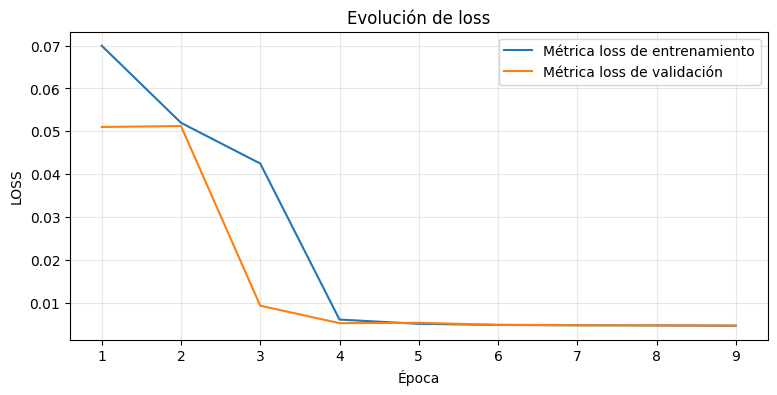

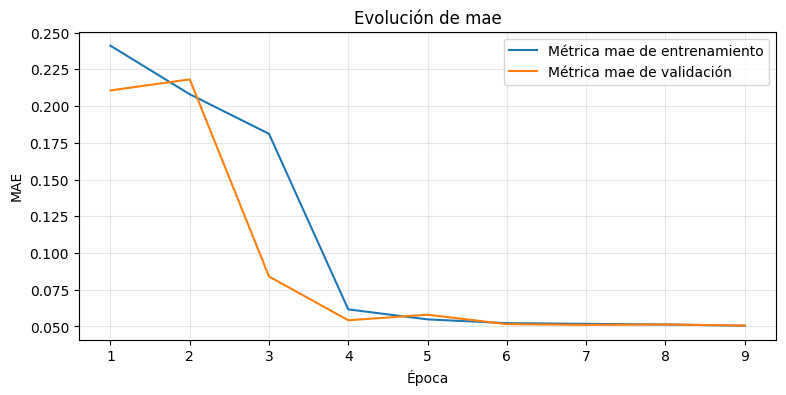

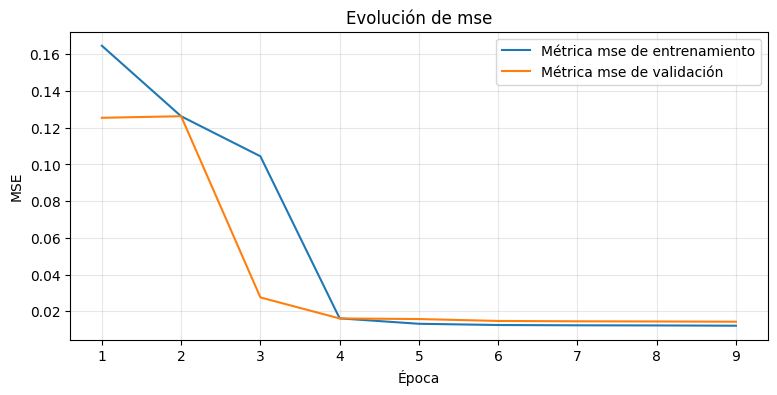

In [113]:
from model_functions import plot_training_metrics

plot_training_metrics(model_data_att)

In [114]:
from services.checkpoints import save_training_summary

test_results_rnn_attention = model_birnn_attention.evaluate(
    X_test_rnn,
    y_test_norm_median_spec,
    verbose=1,
    return_dict=True
)

# Las métricas de test se añaden al resumen del entrenamiento
save_training_summary(
    ATTENTION_SUMMARY_PATH,
    model_data_att,
    test_results_rnn_attention,
    model_path=ATTENTION_MODEL_PATH,
    history_path=ATTENTION_HISTORY_PATH,
    batch_size=batch_size
)

print(test_results_rnn_attention)

128/128 ━━━━━━━━━━━━━━━━━━━━ 15s 99ms/step - loss: 0.0045 - mae: 0.0503 - mse: 0.0113
{'loss': 0.004514295142143965, 'mae': 0.05033120885491371, 'mse': 0.01126489881426096}


In [125]:
from services.normalization import denormalize, normalize
from services.predictions import predict_test_set, save_predictions

# Predicciones del modelo bidireccional con atención. `AttentionPooling` es una
# capa propia, así que Keras necesita recibirla para reconstruir el modelo a
# partir del `.keras`: esta celda necesita también la que define la capa.
y_pred_spec_birnn_attention = predict_test_set(
    ATTENTION_MODEL_PATH,
    TEST_DATA_PATH,
    build_input=lambda test: normalize(
        test["X_test"], test["X_scale_test"]
    )[..., None],
    denormalize=lambda y_norm, test: denormalize(y_norm, test["y_scale_test"]),
    custom_objects={"AttentionPooling": AttentionPooling}
)

save_predictions(ATTENTION_PREDICTIONS_PATH, y_pred=y_pred_spec_birnn_attention)

128/128 ━━━━━━━━━━━━━━━━━━━━ 17s 119ms/step


PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/data/predictions/birnn-attention_predictions.npz')

In [117]:
from iSpec_functions import (
    analyze_sample_real_vs_pred,
    load_ispec_resources,
    load_gaia_table
)

# Los dos cargadores guardan en caché de módulo lo que leen, así que repetir
# aquí la llamada no vuelve a leer del disco los recursos de iSpec ni la tabla
# de Gaia: solo recupera lo que ya cargó la primera sección que los pidiera
resources = load_ispec_resources()
gaia_data_df = load_gaia_table()

results_df_birnn_attention = analyze_sample_real_vs_pred(   
    y_test,
    y_pred_spec_birnn_attention,
    X_id_test,
    gaia_data_df,
    sdss_wavelength,
    resources,
    sample_size=250
)

Espectros analizados:   0%|          | 0/250 [00:00<?, ?cuerpos estelares/s]

Error analizando espectro real
Error analizando espectro real



Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real
Error analizando espectro real


[2026-09-02 06:51:44,794] [WARNING] [atmospheres:_interpolate:110]: Target point '6893.237824229543 4.402071244162561 -5.5 0.4' is out of bound, using the closest
GAUSSJ: Singular Matrix-1
. . . now exiting to system . . .
[2026-09-02 06:51:45,953] [ERROR] [spectrum:generate_spectrum:144]: The synthetic spectrum generation has failed for these astrophysical parameters.


Error analizando espectro real
Espectros analizados: 250 | ajustes del espectro real reutilizados: 250


In [118]:
ATTENTION_ISPEC_PATH.parent.mkdir(parents=True, exist_ok=True)

results_df_birnn_attention.to_csv(
    ATTENTION_ISPEC_PATH,
    index=False
)

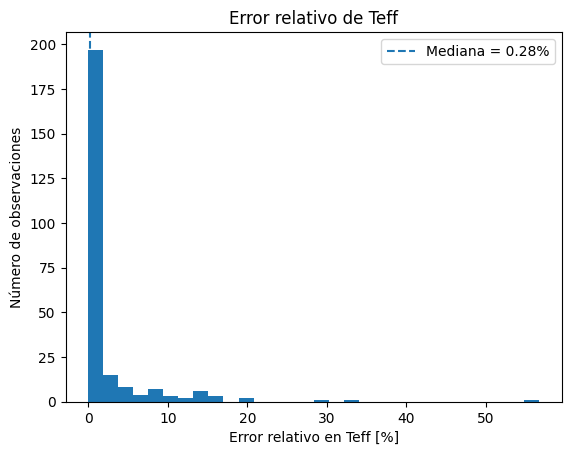

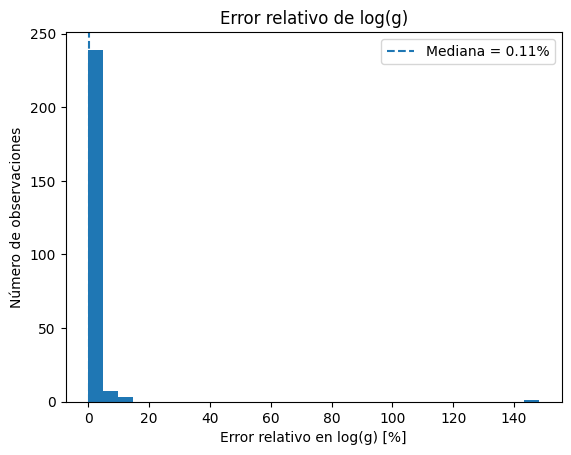

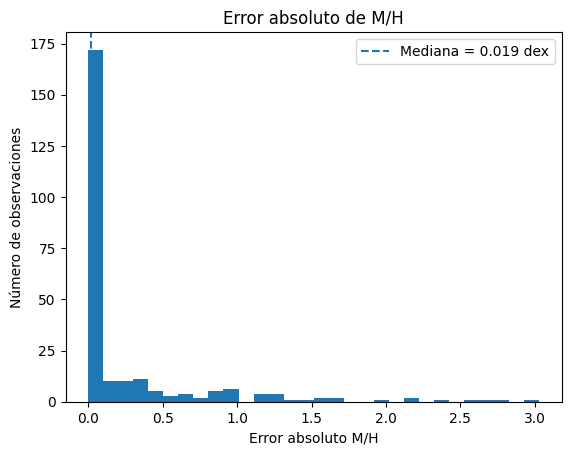

In [119]:
from iSpec_functions import analyze_ispec_errors

error_birnn_attention = analyze_ispec_errors(results_df_birnn_attention)

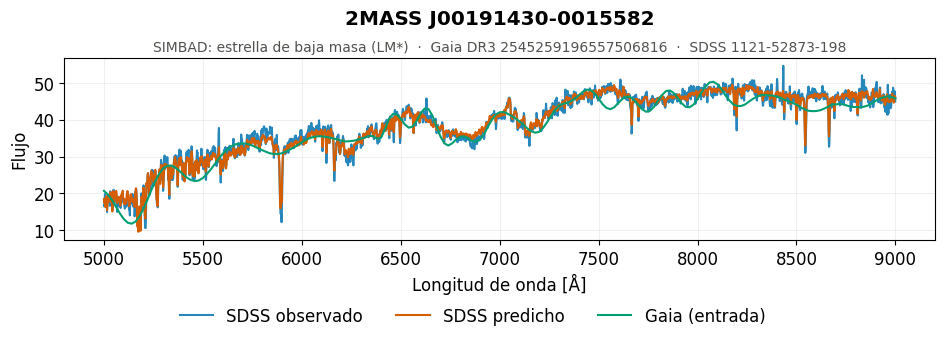

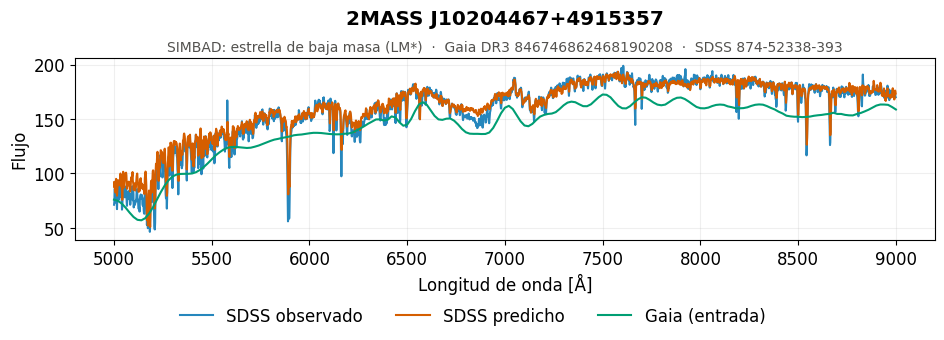

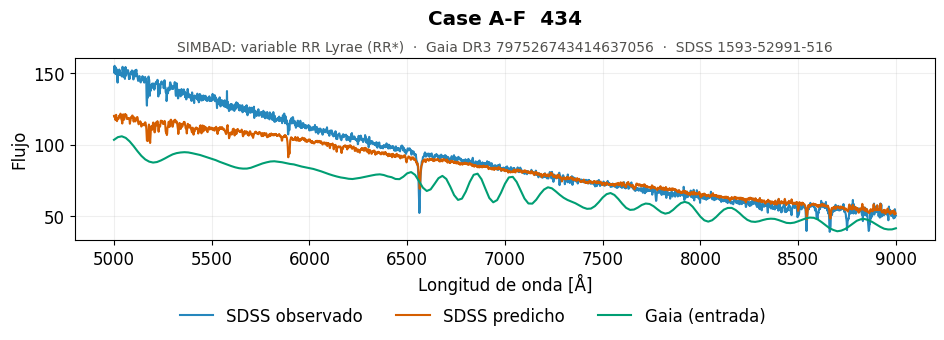

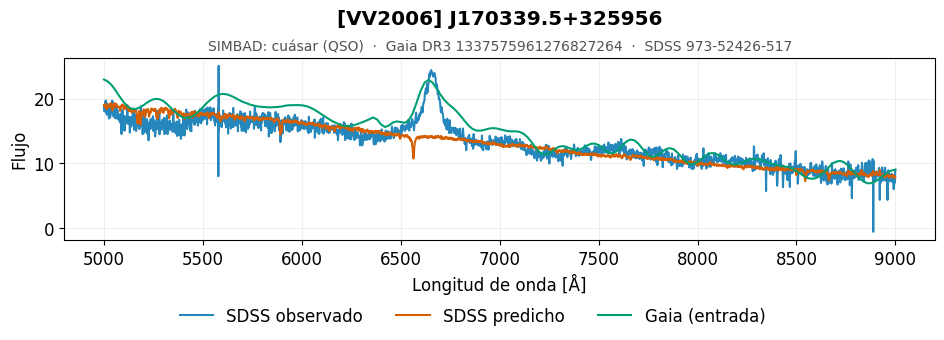

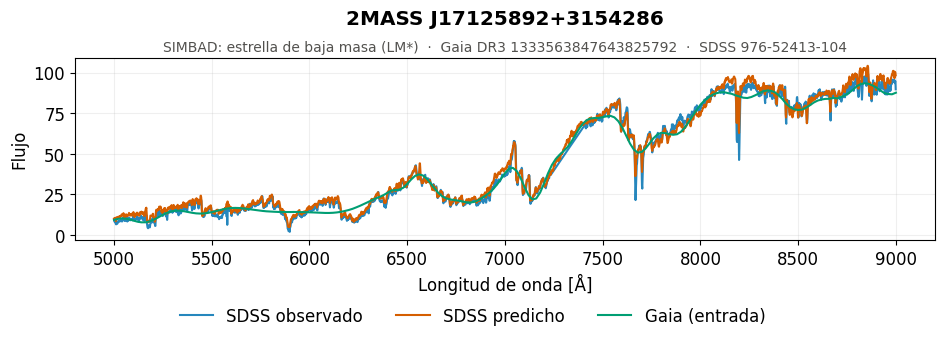

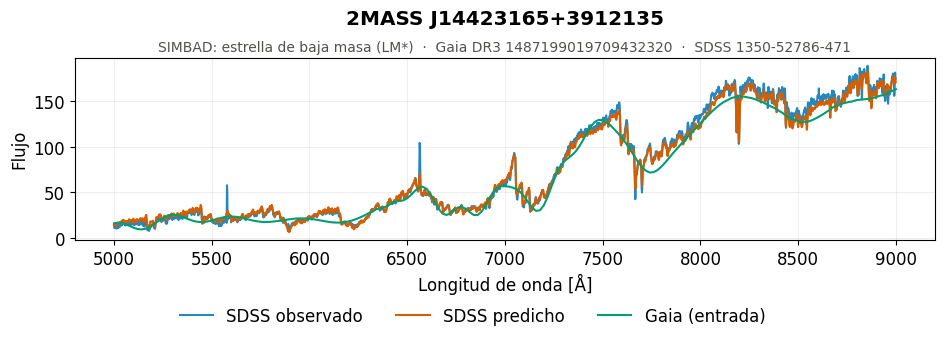

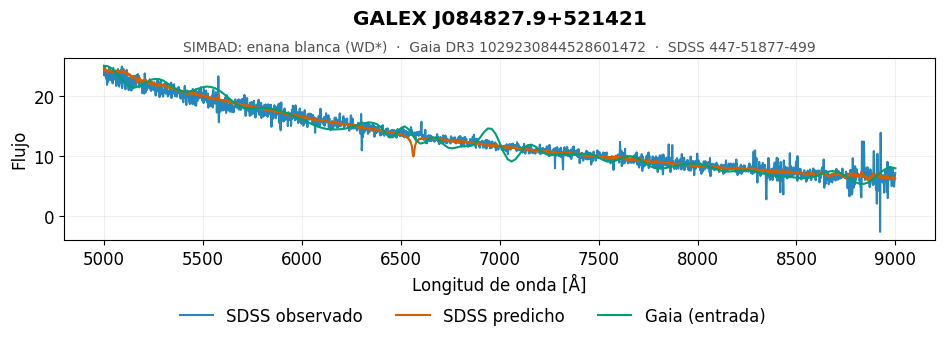

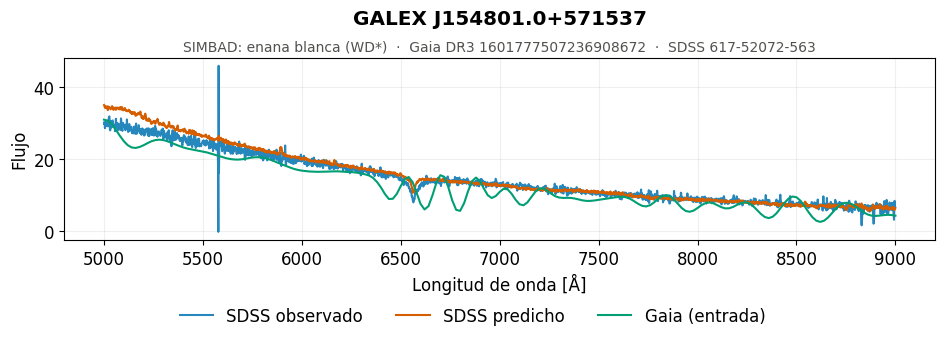

Imágenes guardadas en /home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images


[PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn-attention_main_sequence_central_2545259196557506816.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn-attention_main_sequence_central_846746862468190208.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn-attention_main_sequence_left_797526743414637056.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn-attention_main_sequence_left_1337575961276827264.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn-attention_main_sequence_right_1333563847643825792.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images/birnn-attention_main_sequence_right_1487199019709432320.png'),
 PosixPath('/home/javier-cacho/repos/master-ia/trabajo-fin-master/solution/models/images

In [4]:
import sys

# 'plotting.py' vive en 'solution/services', y la celda de rutas solo añade
# 'models' a 'sys.path'. Las dos carpetas se llaman 'services', así que Python
# las une en un único paquete del que salen tanto 'services.paths' como
# 'services.plotting'
sys.path.insert(0, str(SOLUTION_DIR))

from services.plotting import SELECTED_OBJECTS_PATH, plot_selected_objects

# Comparativa sobre los mismos objetos en todos los cuadernos: la pareja de
# cada zona del diagrama HR que eligió 'services/simbad.py', encabezada por el
# nombre celeste oficial de cada objeto. Las figuras quedan guardadas en
# 'models/images' con el nombre que cita la memoria.
#
# La celda parte del CSV de objetos y de los `.npz` de test y de predicciones,
# así que se ejecuta suelta tras la de rutas: no reentrena, no vuelve a cargar
# el `.npz` de datos completo y no necesita las variables que dejen en memoria
# las demás celdas del cuaderno.
plot_selected_objects(
    SELECTED_OBJECTS_PATH,
    TEST_DATA_PATH,
    ATTENTION_PREDICTIONS_PATH,
    "birnn-attention"
)
